# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [1]:
# Import the four packages here.
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path 

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [2]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"

# Read the boundary.
maine_boundary = gpd.read_file(boundary_path)

# Print its CRS and shape.
print(maine_boundary.crs)
print(maine_boundary.shape)

# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()
print(maine_boundary.shape)

EPSG:4326
(6204, 10)
(1, 10)


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [3]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [4]:
print("dimensions: ", bio1.dims)
print("shape: ", bio1.shape)
print("data type: ", bio1.dtype)
print("crs: ", bio1.rio.crs)
print("resolution: ", bio1.rio.resolution())
print("bounds: ", bio1.rio.bounds())
print("nodata: ", bio1.rio.nodata)

dimensions:  ('band', 'y', 'x')
shape:  (1, 4320, 8640)
data type:  float32
crs:  EPSG:4326
resolution:  (0.041666666666666664, -0.041666666666666664)
bounds:  (-180.0, -89.99999999999997, 180.0, 90.0)
nodata:  nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [5]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [6]:
print("global dimensions: ", bio1.dims)
print("clipped dimensions: ", bio1_maine.dims)
print("global shape: ", bio1.shape)
print("clipped shape: ", bio1_maine.shape)
print("global data type: ", bio1.dtype)
print("clipped data type: ", bio1_maine.dtype)
print("global crs: ", bio1.rio.crs)
print("clipped crs: ", bio1_maine.rio.crs)
print("global resolution: ", bio1.rio.resolution())
print("clipped resolution: ", bio1_maine.rio.resolution())
print("global bounds: ", bio1.rio.bounds())
print("clipped bounds: ", bio1_maine.rio.bounds())
print("global nodata: ", bio1.rio.nodata)
print("clipped nodata: ", bio1_maine.rio.nodata)


global dimensions:  ('band', 'y', 'x')
clipped dimensions:  ('y', 'x')
global shape:  (1, 4320, 8640)
clipped shape:  (109, 101)
global data type:  float32
clipped data type:  float64
global crs:  EPSG:4326
clipped crs:  EPSG:4326
global resolution:  (0.041666666666666664, -0.041666666666666664)
clipped resolution:  (0.04166666666666671, -0.041666666666666664)
global bounds:  (-180.0, -89.99999999999997, 180.0, 90.0)
clipped bounds:  (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
global nodata:  nan
clipped nodata:  nan


**Your comparison:** The CRS, resolution, and nodata values stayed the same. The dimensions, shape, data type, and bounds all changed. Interestingly the datatype increased from float32 to float64 while the other properties were reduced.

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

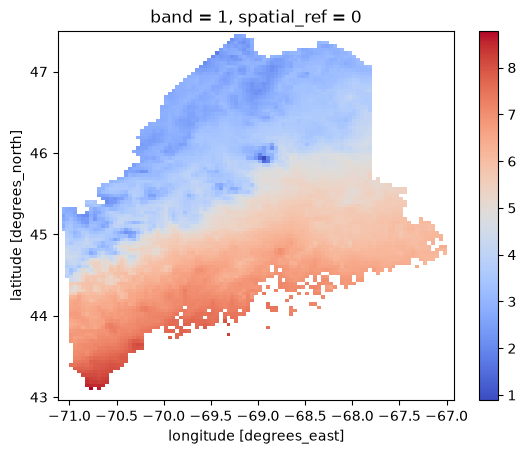

In [7]:
bio1_maine.plot(cmap = "coolwarm")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** BIO5 = Max Temperature of Warmest Month. Amphibians are ectotherms, so if the ambient temperature is extreme they may not survive. Maximum temperatures during the warmest could surpass certain species' heat tolerance thresholds.

**Variable 2 and justification:** BIO6 = Min Temperature of Coldest Month. Similar to the max temperature of the warmest month, the min temperature of the coldest month may surpass a species' cold tolerance threshold.

**Variable 3 and justification:** BIO17 = Precipitation of Driest Quarter. This will affect availability of water bodies for amphibian habitats.

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [8]:
# Open raster
bio5_path = bioclim_path / "wc2.1_2.5m_bio_5.tif"
bio5 = rxr.open_rasterio(
    bio5_path,
    masked=True,
)

# inspect metadata
print("dimensions: ", bio5.dims)
print("shape: ", bio5.shape)
print("data type: ", bio5.dtype)
print("crs: ", bio5.rio.crs)
print("resolution: ", bio5.rio.resolution())
print("bounds: ", bio5.rio.bounds())
print("nodata: ", bio5.rio.nodata)

dimensions:  ('band', 'y', 'x')
shape:  (1, 4320, 8640)
data type:  float32
crs:  EPSG:4326
resolution:  (0.041666666666666664, -0.041666666666666664)
bounds:  (-180.0, -89.99999999999997, 180.0, 90.0)
nodata:  nan


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [9]:
print("dimensions: ", bio1.dims == bio5.dims)
print("shape: ", bio1.shape == bio5.shape)
print("data type: ", bio1.dtype == bio5.dtype)
print("crs: ", bio1.rio.crs == bio5.rio.crs)
print("resolution: ", bio1.rio.resolution() == bio5.rio.resolution())
print("bounds: ", bio1.rio.bounds() == bio5.rio.bounds())
print("nodata: ", bio1.rio.nodata == bio5.rio.nodata)

print("bio1:", repr(bio1.rio.nodata), type(bio1.rio.nodata))
print("bio5:", repr(bio5.rio.nodata), type(bio5.rio.nodata)) # says nodata values are different but they look the same
# research led to descovery that nan is always unequal to everything, so this is ok for now

dimensions:  True
shape:  True
data type:  True
crs:  True
resolution:  True
bounds:  True
nodata:  False
bio1: np.float32(nan) <class 'numpy.float32'>
bio5: np.float32(nan) <class 'numpy.float32'>


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

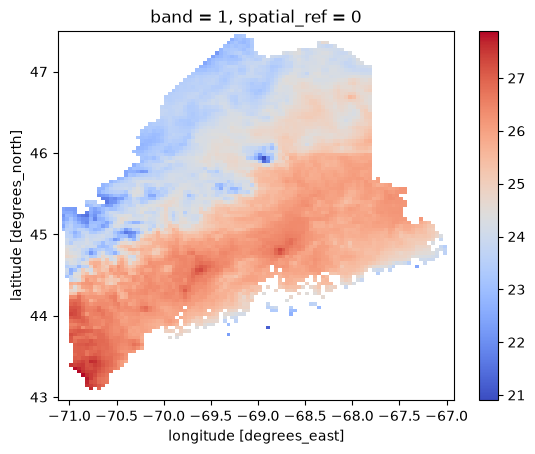

In [10]:
# clip
bio5_maine = bio5.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

# squeeze
bio5_maine = bio5_maine.squeeze()

# plot
bio5_maine.plot(cmap = "coolwarm")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

dimensions:  True
shape:  True
data type:  True
crs:  True
resolution:  True
bounds:  True
nodata:  nan
nodata:  nan


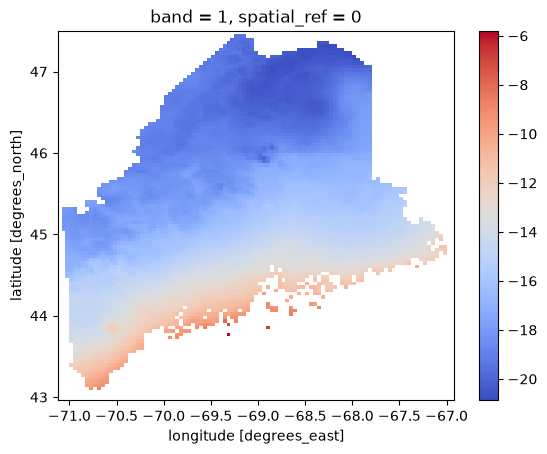

In [11]:
# Open raster
bio6_path = bioclim_path / "wc2.1_2.5m_bio_6.tif"
bio6 = rxr.open_rasterio(
    bio6_path,
    masked=True,
)

# check alignment
print("dimensions: ", bio1.dims == bio6.dims)
print("shape: ", bio1.shape == bio6.shape)
print("data type: ", bio1.dtype == bio6.dtype)
print("crs: ", bio1.rio.crs == bio6.rio.crs)
print("resolution: ", bio1.rio.resolution() == bio6.rio.resolution())
print("bounds: ", bio1.rio.bounds() == bio6.rio.bounds())
print("nodata: ", bio1.rio.nodata)
print("nodata: ", bio6.rio.nodata)

# clip
bio6_maine = bio6.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

# squeeze
bio6_maine = bio6_maine.squeeze()

# plot
bio6_maine.plot(cmap = "coolwarm")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

dimensions:  True
shape:  True
data type:  True
crs:  True
resolution:  True
bounds:  True
nodata:  nan
nodata:  nan


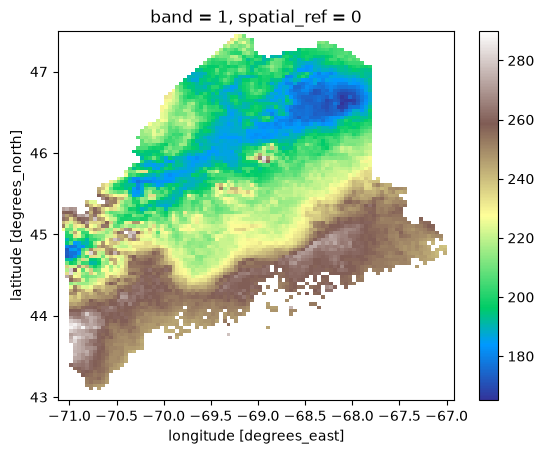

In [12]:
# Open raster
bio17_path = bioclim_path / "wc2.1_2.5m_bio_17.tif"
bio17 = rxr.open_rasterio(
    bio17_path,
    masked=True,
)

# check alignment
print("dimensions: ", bio1.dims == bio17.dims)
print("shape: ", bio1.shape == bio17.shape)
print("data type: ", bio1.dtype == bio17.dtype)
print("crs: ", bio1.rio.crs == bio17.rio.crs)
print("resolution: ", bio1.rio.resolution() == bio17.rio.resolution())
print("bounds: ", bio1.rio.bounds() == bio17.rio.bounds())
print("nodata: ", bio1.rio.nodata)
print("nodata: ", bio17.rio.nodata)

# clip
bio17_maine = bio17.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

# squeeze
bio17_maine = bio17_maine.squeeze()

# plot
bio17_maine.plot(cmap = "terrain")

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [13]:
amphibians = gpd.read_file(
    "../assignments/Amphibians_ME/Amphibians_ME.csv",
    x_possible_names="decimalLongitude",
    y_possible_names="decimalLatitude",
).set_crs("EPSG:4326")

# Keep the five requested columns.
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
    "geometry",
]

amphibians = amphibians[columns_to_keep]
amphibians.shape

(25972, 6)

## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [14]:
# Convert both coordinate columns with pd.to_numeric().
## No longer necessary because imported the csv file with gpd.read_file

# Drop rows missing species, longitude, or latitude.
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()

amphibians.shape

(25972, 6)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [15]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
                               386
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Name: count, dtype: int64

**Species 1:** Dryophytes versicolor (gray treefrog)

**Species 2:** Notophthalmus viridescens (eastern newt)

**Species 3:** Anaxyrus americanus (american toad)

In [16]:
selected_species = [
    "Dryophytes versicolor",
    "Notophthalmus viridescens",
    "Anaxyrus americanus",
]

# Filter the occurrence table with .isin(selected_species).
selected_amphibians = amphibians[
    amphibians["species"].isin(selected_species)]

selected_amphibians.shape

(5240, 6)

## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [17]:
# Create selected_amphibians_gdf here.
## already done when importing gdf

## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [18]:
# Print both coordinate systems.
print(selected_amphibians.crs)
print(bio5_maine.rio.crs)
print(bio6_maine.rio.crs)
print(bio17_maine.rio.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


**Your explanation:** Before extracting raster values, we have to make sure that the bounds, dimensions, spatial resolution, and nodata values are also the same.

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [19]:
# Create point_x from point longitude.
point_x = xr.DataArray(
    selected_amphibians.geometry.x.to_numpy(),
    dims="record",
)

# Create point_y from point latitude.
point_y = xr.DataArray(
    selected_amphibians.geometry.y.to_numpy(),
    dims="record",
)

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [20]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians["annual_mean_temp_C"] = bio1_values

## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [21]:
# Count missing extracted BIO1 values.
selected_amphibians["annual_mean_temp_C"].isna().value_counts()

annual_mean_temp_C
False    4880
True      360
Name: count, dtype: int64

**Your explanation:** Coastal occurances may be assigned NoData because the WorldClim data is terrestrial, and the scale of the raster data may not be suitable to include small islands or detailed coastlines in the terrestrial dataset.

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [22]:
# Extract values from the first additional clipped raster.
bio5_values = bio5_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians["warmest_max_temp_C"] = bio5_values

In [23]:
# Extract values from the first additional clipped raster.
bio6_values = bio6_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians["coldest_min_temp_C"] = bio6_values

In [24]:
# Extract values from the first additional clipped raster.
bio17_values = bio17_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians["driest_quarter_precip_mm"] = bio17_values

## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [25]:
# Create and display occurrence_environment.
occurrence_environment = selected_amphibians.drop(columns="geometry")
occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,annual_mean_temp_C,warmest_max_temp_C,coldest_min_temp_C,driest_quarter_precip_mm
5,6520714657,Dryophytes versicolor,-68.773346,44.615650,2026,6.803500,26.136000,-12.820,260.0
8,6520678362,Dryophytes versicolor,-68.720969,44.611887,2026,6.809333,26.219999,-12.912,258.0
10,6520667379,Anaxyrus americanus,-69.794576,44.203264,2026,7.080667,26.248001,-12.668,254.0
23,6520596403,Anaxyrus americanus,-70.456821,43.994143,2026,6.875500,26.136000,-13.396,258.0
25,6520578080,Dryophytes versicolor,-70.589287,43.319987,2026,8.071000,26.840000,-10.260,252.0


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [26]:
predictor_columns = [
    "annual_mean_temp_C",
    "warmest_max_temp_C",
    "coldest_min_temp_C",
    "driest_quarter_precip_mm",
]

for species, samples in occurrence_environment.groupby("species"):
    print("Mean: ", species, len(samples), "\n", samples[predictor_columns].mean())

Mean:  Anaxyrus americanus 2800 
 annual_mean_temp_C            5.911439
warmest_max_temp_C           25.408857
coldest_min_temp_C          -14.351806
driest_quarter_precip_mm    239.110392
dtype: float64
Mean:  Dryophytes versicolor 1411 
 annual_mean_temp_C            6.704224
warmest_max_temp_C           26.070453
coldest_min_temp_C          -13.174314
driest_quarter_precip_mm    247.354312
dtype: float64
Mean:  Notophthalmus viridescens 1029 
 annual_mean_temp_C            6.461556
warmest_max_temp_C           25.544018
coldest_min_temp_C          -13.196836
driest_quarter_precip_mm    244.753623
dtype: float64


## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [27]:
# Select the four predictor columns and calculate .corr().
occurrence_environment[predictor_columns].corr().round(2)

,annual_mean_temp_C,warmest_max_temp_C,coldest_min_temp_C,driest_quarter_precip_mm
annual_mean_temp_C,1.00,0.70,0.94,0.63
warmest_max_temp_C,0.70,1.00,0.43,0.33
coldest_min_temp_C,0.94,0.43,1.00,0.66
driest_quarter_precip_mm,0.63,0.33,0.66,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. Annual mean temp is highly correlated with coldest month min temp; moderately correlated wtih warmest month max temp; and slightly correlated wtih driest quarter precip.  I would probably remove annual mean temp for my analysys and keep the other two temperature variables because they are not correlated wtih one another.

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [28]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,
)

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact? Each relies on the resolution of the other, and the dataset with the lowest spatial resolution sets the bar for the resolution that the data can be plotted at. If coordinates have low uncertainty but the raster resoution is low, the coordinates can only be analyzed at the raster's lower resolution. If the opposite is true and the coordinates have high uncertainty but the raster resolution is high, then caution should be used when assigning raster values to coordinates with high uncertainty because they may not truly fall in that raster cell.
2. What environmental variation is lost when all occurrences in one raster cell receive the same value? There could be small scale environmental variation in elevation, slope angles, or vegetation communities that are lost when occurrences in one cell all receive the same value.
3. Which predictor has the strongest biological justification for your selected species? I'm not an amphibian expert, but I think that minimum temperature during the coldest month is the most important factor in amphibian occurrences because they are ectotherms that likely have strict minimum temperature thresholds. Mean annual temperature is probably not a strong variable because it is uninformative about hot and cold extremes.
4. Which preprocessing choice is most important to document for reproducibility? I would say that the way that NoData values are handled is very important to document, because readers should know whether they were removed, given data by averaging nearby cells, or if their values were assigned in another way.
5. Name one additional environmental predictor you would seek for an amphibian study and explain why. I would want to know the first thaw dates in spring because this may affect amphibian migration to breeding areas.

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```